# Generating the tracker test dataset

In this notebook, we draw a sample of floes from the validation dataset in order to test the geometric matching functions. The results are temporarily saved to the data folder, but will be added to the package.


In [62]:
using Pkg
Pkg.activate("../scripts/calval")
# Pkg.update(; name="IceFloeTracker", rev="main")
using IceFloeTracker
using Images
using Random
using DataFrames
using StatsBase
using CairoMakie

include("../scripts/dev/segmentation.jl")



  Activating project at `~/Documents/research/calval_tgrs/scripts/calval`


colorize_classification (generic function with 1 method)

In [40]:
dataset = Watkins2026Dataset(;
    url="https://github.com/danielmwatkins/ice-floe-validation-dataset/",
    ref="main",
    cache_dir="/tmp/Watkins2026",
    metadata_path="data/validation_dataset/validation_dataset.csv",
)

tc_imgs = modis_truecolor.(dataset);
fc_imgs = modis_falsecolor.(dataset);
lm_imgs = modis_landmask.(dataset);
binary_floes = validated_binary_floes.(dataset);
fill_missing!(binary_floes)
nothing

In [76]:
# Remove floes touching boundaries
binary_floes .= clearborder.(binary_floes);

In [77]:
labeled_floes = label_components.(binary_floes);

In [58]:
dataset.info.lookup_index = 1:nrow(dataset.info)

1:378

In [42]:
classifier = Classify()
classified_image = classifier.(fc_imgs, lm_imgs .|> r -> Gray.(r) .> 0)
masks = [Dict(k => ci .== classifier.key[k] for k in keys(classifier.key)) for ci in classified_image];

In [ ]:
dfs = extended_regionprops_table.(
    labeled_floes,
    fc_imgs,
    masks);

In [79]:
for (idx, data) in enumerate(eachrow(dataset.info))
    if nrow(dfs[idx]) > 0 
        dfs[idx].satellite .= data.satellite
        dfs[idx].case_number .= data.case_number
    end
end

In [113]:
df_all = vcat(dfs...; cols=:union);
df_all[:, :length_scale_km] = df_all[:, :length_scale] .* 0.25
println("Number of floes: ", nrow(df_all))
println("Number of clear-sky floes: ", nrow(subset(df_all, :cloud_fraction => ByRow(r -> r .< 0.01))))

Number of floes: 5108
Number of clear-sky floes: 3022


Out of the 5,100 labeled floes, 3,000 are not covered by cloud. From these, we need to identify which we can track across a pair of images. One method would be to use the regular settings in the tracker on each image, then filtering the result. Alternatively, we can focus only on those with a floe in the relevant set, and find the best match.

To select these options, I can subset the data to only those with at least some clear-sky floes and which have floes both days.

In [114]:
# cloud-free
subset!(df_all, :cloud_fraction => r -> r .< 0.01)

# check if floes in both images
transform!(groupby(df_all, :case_number), :satellite => (r -> length(unique(r))) => :n_images)

# take only the ones with floes in both
subset!(df_all, :n_images => r -> r .== 2);

In [115]:
println("Number of clear-sky floes: ", nrow(df_all))

Number of clear-sky floes: 2885


In [ ]:
for case_number in unique(df_all.case_number)
    idx1, idx2 = dataset.info[dataset.info.case_number .== case_number, :lookup_index]


2-element Vector{Int64}:
 125
 126

In [109]:
idx1 = 125
idx2 = 126
comp_df = compare_objects(dfs[idx1], dfs[idx2], labeled_floes[idx1], labeled_floes[idx2])

Row,s1_label,s1_area,s1_row_centroid,s1_col_centroid,s1_max_col,s1_max_row,s1_min_col,s1_min_row,s1_probability,s2_label,s2_area,s2_row_centroid,s2_col_centroid,s2_max_col,s2_max_row,s2_min_col,s2_min_row,s2_probability,s1_s2_dist,s1_s2_area_overlap,s1_area_fraction,s2_area_fraction
,Int64,Int64,Float64,Float64,Int64,Int64,Int64,Int64,Float64,Int64,Int64,Float64,Float64,Int64,Int64,Int64,Int64,Float64,Float64,Int64,Float64,Float64
1,1,1361,255.456,27.1506,47,280,6,233,0.994457,1,1338,256.223,28.201,48,281,8,234,0.992702,1.30075,1297,0.952976,0.969357
2,2,144,17.6389,27.0347,35,25,20,11,0.837419,2,157,20.0764,28.3376,36,28,21,12,0.847113,2.76388,119,0.826389,0.757962
3,3,204,8.56863,39.652,48,15,31,2,0.905083,3,217,10.4562,39.5991,49,18,31,3,0.910824,1.88833,175,0.857843,0.806452
4,4,174,224.057,36.3391,42,234,32,214,0.855752,4,157,225.822,37.8854,42,235,34,216,0.877452,2.34591,130,0.747126,0.828025
5,5,87,385.126,41.5862,46,391,37,380,0.743788,5,77,385.13,41.987,46,390,38,380,0.811539,0.400821,75,0.862069,0.974026
6,6,161,210.317,46.8137,52,219,42,202,0.81674,6,154,210.753,47.3961,53,219,42,203,0.775613,0.727837,140,0.869565,0.909091
7,7,118,138.237,50.4153,56,143,44,133,0.829106,7,91,138.901,51.5714,57,143,46,134,0.836108,1.33319,88,0.745763,0.967033
8,9,69,34.2754,56.7246,62,38,51,31,0.760563,8,83,35.8916,58.7349,65,41,52,32,0.757859,2.57942,56,0.811594,0.674699
9,11,211,242.005,60.545,67,251,54,232,0.890366,9,237,241.945,60.6203,68,252,54,231,0.905155,0.0959721,202,0.957346,0.852321


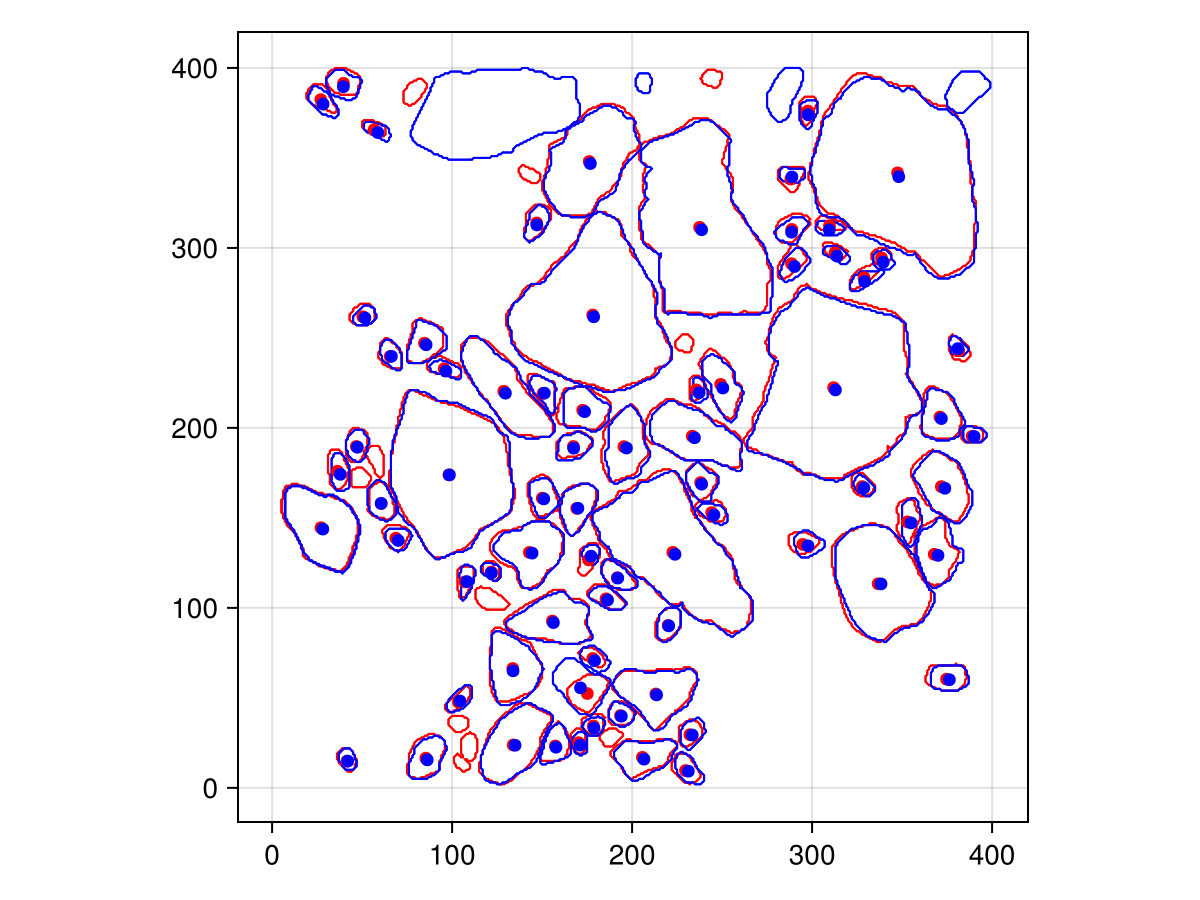

In [111]:
# visualize result

f = Figure()
ax = CairoMakie.Axis(f[1,1], aspect=1)
contour!(ax, rotr90(labeled_floes[idx1]), color=:red, levels=[0, 0.5])
contour!(ax, rotr90(labeled_floes[idx2]), color=:blue, levels=[0, 0.5])
# Image coordinates are reversed from math display, so subtract from 400
scatter!(ax, comp_df.s1_col_centroid, 400 .- comp_df.s1_row_centroid, color=:red)
scatter!(ax, comp_df.s2_col_centroid, 400 .- comp_df.s2_row_centroid, color=:blue)

f